# Thesis outputs — tables and figures


In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path('..').resolve()
DATA = PROJECT_ROOT / 'data'

MODELS = [
    ('gemini_flash',       'Gemini 2.5 Flash',      'Gemini Flash'),
    ('gemini_flash_lite',  'Gemini 2.5 Flash Lite', 'Gemini Flash Lite'),
    ('gpt54_mini',         'GPT-5.4 Mini',          'GPT-5.4 Mini'),
    ('gpt54_nano',         'GPT-5.4 Nano',          'GPT-5.4 Nano'),
    ('grok4_fast',         'Grok 4 Fast',           'Grok 4 Fast'),
    ('grok_fast',          'Grok 3 Fast',           'Grok 3 Fast'),
]

FRAMES = {mid: pd.read_csv(DATA / f'{mid}_recipes_calculated.csv') for mid, _, _ in MODELS}
ALL = pd.concat(FRAMES.values(), ignore_index=True)
ALL['fsa_cat'] = ALL['calculated_fsa_category'].astype(str).str.lower()
ALL['category'] = ALL['category'].astype(str).str.lower()

print(f'Loaded {len(MODELS)} models, {len(ALL):,} total recipes.')

# --- extra setup for the figure cells copied from score_comparison / explore ---
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

df_all = ALL
all_df = ALL
files = {full: str(DATA / f"{mid}_recipes_calculated.csv") for mid, full, _ in MODELS}
models = [full for _, full, _ in MODELS]
df_liste = [FRAMES[mid] for mid, _, _ in MODELS]
MODEL_LABELS = {mid: full for mid, full, _ in MODELS}
order = ["healthy", "moderate", "unhealthy"]
width = 0.35


Loaded 6 models, 5,603 total recipes.


## Table 3.1 — Generated dataset before filtering

In [2]:
rows = []
tot = [0, 0, 0, 0]
for mid, full, _ in MODELS:
    cat = pd.read_csv(DATA / f"{mid}_recipes_raw.csv")["category"].astype(str).str.lower()
    b = int((cat == "breakfast").sum()); d = int((cat == "dinner").sum()); de = int((cat == "dessert").sum())
    rows.append([full, b, d, de, b + d + de])
    tot = [tot[0] + b, tot[1] + d, tot[2] + de, tot[3] + b + d + de]
rows.append(["Total", tot[0], tot[1], tot[2], tot[3]])
df_31 = pd.DataFrame(rows, columns=["Model", "Breakfast", "Dinner", "Dessert", "Total"])
print("--- Table 3.1: Generated dataset before filtering ---")
print(df_31.to_string(index=False))


--- Table 3.1: Generated dataset before filtering ---
                Model  Breakfast  Dinner  Dessert  Total
     Gemini 2.5 Flash        150     620      265   1035
Gemini 2.5 Flash Lite        150     620      265   1035
         GPT-5.4 Mini        150     620      265   1035
         GPT-5.4 Nano        150     620      265   1035
          Grok 4 Fast        150     620      265   1035
          Grok 3 Fast        150     620      265   1035
                Total        900    3720     1590   6210


## Table 3.3 — Generation time, tokens, cost, average ingredients

In [3]:
timing = pd.read_csv(DATA / "generation_timing.csv").set_index("model")
rows = []
for mid, full, _ in MODELS:
    t = timing.loc[mid]
    raw = pd.read_csv(DATA / f"{mid}_recipes_raw.csv")
    avg_ing = raw["ingredients_json"].apply(lambda s: len(json.loads(s))).mean()
    rows.append([full, f"{t['elapsed_minutes']:.0f}", f"{int(t['total_tokens']):,}",
                 f"{t['estimated_cost_usd']:.2f}", f"{avg_ing:.1f}"])
df_33 = pd.DataFrame(rows, columns=["Model", "Time (min)", "Total tokens", "Cost (USD)", "Avg ingredients/recipe"])
print("--- Table 3.3: Generation time, tokens, cost, average ingredients ---")
print(df_33.to_string(index=False))


--- Table 3.3: Generation time, tokens, cost, average ingredients ---
                Model Time (min) Total tokens Cost (USD) Avg ingredients/recipe
     Gemini 2.5 Flash        396    1,860,412      11.68                   13.1
Gemini 2.5 Flash Lite         51    1,768,355       0.99                   12.2
         GPT-5.4 Mini         75    1,614,557       3.94                   14.5
         GPT-5.4 Nano         96    1,601,017       1.07                   13.0
          Grok 4 Fast         96    1,706,436       0.54                   11.9
          Grok 3 Fast        216    1,600,520       3.42                   11.7


## Table 3.4 — Recipe retention per model

In [4]:
rows = []
total_gen, total_kept = 0, 0
for mid, full_label, _ in MODELS:
    raw = pd.read_csv(DATA / f'{mid}_recipes_raw.csv')
    kept = FRAMES[mid]
    g, k = len(raw), len(kept)
    rows.append([full_label, g, k, f'{100*k/g:.1f}'])
    total_gen += g; total_kept += k
rows.append(['Total', total_gen, total_kept, f'{100*total_kept/total_gen:.1f}'])

df_retention = pd.DataFrame(rows, columns=['Model', 'Recipes generated', 'Recipes retained', 'Retention (%)'])
print('--- Table 3.4: Recipes retained ---')
print(df_retention.to_string(index=False))

--- Table 3.4: Recipes retained ---
                Model  Recipes generated  Recipes retained Retention (%)
     Gemini 2.5 Flash               1035               884          85.4
Gemini 2.5 Flash Lite               1035               888          85.8
         GPT-5.4 Mini               1035               976          94.3
         GPT-5.4 Nano               1035               877          84.7
          Grok 4 Fast               1035               972          93.9
          Grok 3 Fast               1035              1006          97.2
                Total               6210              5603          90.2


## Table 5.1 — Mean Accuracy, MAPE, R² per nutrient (averaged across models)

In [5]:
NUTRIENTS = [
    ('claimed_energy_kcal','calculated_calories.quantity','Energy (kcal/100g)'),
    ('claimed_protein_g','calculated_protein','Protein (g/100g)'),
    ('claimed_carbs_g','calculated_carbohydrate','Carbohydrates (g/100g)'),
    ('claimed_fat_g','calculated_fat','Fat (g/100g)'),
    ('claimed_sugar_g','calculated_sugar_total','Sugar (g/100g)'),
    ('claimed_fiber_g','calculated_dietary_fibre','Fibre (g/100g)'),
]

def mape(c,k):
    m = (k>0)&c.notna()&k.notna(); return 100*np.mean(np.abs((c[m]-k[m])/k[m])) if m.sum() else np.nan
def r2v(c,k):
    m = c.notna()&k.notna()
    if m.sum()<3: return np.nan
    ss_res = np.sum((c[m]-k[m])**2); ss_tot = np.sum((k[m]-k[m].mean())**2)
    return 1-ss_res/ss_tot if ss_tot>0 else np.nan
def acc(c,k):
    m = (k>0)&c.notna()&k.notna(); return 100*np.mean(np.maximum(0, 1-np.abs(c[m]-k[m])/k[m])) if m.sum() else np.nan

rows = []
for c_col, k_col, label in NUTRIENTS:
    accs, mapes, r2s = [], [], []
    for mid, _, _ in MODELS:
        df = FRAMES[mid]; w = df['total_recipe_weight_g']; ok = w>0
        c = df.loc[ok, c_col]/w[ok]*100
        k = df.loc[ok, k_col]/w[ok]*100
        accs.append(acc(c,k)); mapes.append(mape(c,k)); r2s.append(r2v(c,k))
    rows.append([label, f'{np.nanmean(accs):.1f}', f'{np.nanmean(mapes):.1f}', f'{np.nanmean(r2s):.3f}'])

# Sodium (salt → sodium conversion)
accs, mapes, r2s = [], [], []
for mid, _, _ in MODELS:
    df = FRAMES[mid]; w = df['total_recipe_weight_g']; ok = w>0
    c = (df.loc[ok,'claimed_salt_g']*1000.0/2.5)/w[ok]*100
    k = df.loc[ok,'calculated_sodium_(na)']/w[ok]*100
    accs.append(acc(c,k)); mapes.append(mape(c,k)); r2s.append(r2v(c,k))
rows.append(['Sodium (mg/100g)', f'{np.nanmean(accs):.1f}', f'{np.nanmean(mapes):.1f}', f'{np.nanmean(r2s):.3f}'])

df_avg = pd.DataFrame(rows, columns=['Nutrient','Mean Accuracy (%)','MAPE (%)','$R^2$'])
print('--- Table 5.1: Averaged nutrient accuracy ---')
print(df_avg.to_string(index=False))

--- Table 5.1: Averaged nutrient accuracy ---
              Nutrient Mean Accuracy (%) MAPE (%)  $R^2$
    Energy (kcal/100g)              76.8     24.4  0.370
      Protein (g/100g)              76.5     25.7  0.243
Carbohydrates (g/100g)              64.1     64.8  0.251
          Fat (g/100g)              70.2     32.9  0.501
        Sugar (g/100g)              64.7     39.2  0.583
        Fibre (g/100g)              65.4     43.1  0.472
      Sodium (mg/100g)              50.3    114.0 -0.037


## Table 5.2 — Accuracy per model and nutrient

In [6]:
rows = []
for mid, _, label in MODELS:
    df = FRAMES[mid]; w = df['total_recipe_weight_g']; ok = w>0
    for c_col, k_col, n_label in NUTRIENTS:
        c = df.loc[ok, c_col]/w[ok]*100
        k = df.loc[ok, k_col]/w[ok]*100
        rows.append([label, n_label, f'{acc(c,k):.1f}', f'{mape(c,k):.1f}', f'{r2v(c,k):.3f}'])
    # Sodium
    c = (df.loc[ok,'claimed_salt_g']*1000.0/2.5)/w[ok]*100
    k = df.loc[ok,'calculated_sodium_(na)']/w[ok]*100
    rows.append([label, 'Sodium (mg/100g)', f'{acc(c,k):.1f}', f'{mape(c,k):.1f}', f'{r2v(c,k):.3f}'])

df_per_model_nut = pd.DataFrame(rows, columns=['Model','Nutrient','Mean Accuracy (%)','MAPE (%)','$R^2$'])
print('--- Table 5.2: Per-model per-nutrient accuracy ---')
print(df_per_model_nut.to_string(index=False))

--- Table 5.2: Per-model per-nutrient accuracy ---
            Model               Nutrient Mean Accuracy (%) MAPE (%)  $R^2$
     Gemini Flash     Energy (kcal/100g)              87.0     13.6  0.866
     Gemini Flash       Protein (g/100g)              84.6     16.2  0.582
     Gemini Flash Carbohydrates (g/100g)              71.0     48.8  0.836
     Gemini Flash           Fat (g/100g)              78.1     23.1  0.793
     Gemini Flash         Sugar (g/100g)              73.8     27.4  0.947
     Gemini Flash         Fibre (g/100g)              73.2     37.1  0.731
     Gemini Flash       Sodium (mg/100g)              45.3    195.3  0.019
Gemini Flash Lite     Energy (kcal/100g)              66.5     38.1 -1.284
Gemini Flash Lite       Protein (g/100g)              71.2     34.6 -0.117
Gemini Flash Lite Carbohydrates (g/100g)              48.5    104.7 -1.751
Gemini Flash Lite           Fat (g/100g)              62.4     46.1 -0.517
Gemini Flash Lite         Sugar (g/100g)         

## Table 5.3 — Calculated FSA and WHO scores per model

In [7]:
rows = []
tot = dict(n=0, fsa=0, who=0, h=0, m=0, u=0)
for mid, _, label in MODELS:
    df = FRAMES[mid]
    n = len(df)
    fsa = df['calculated_fsa_score'].mean()
    who = df['calculated_who_score'].mean()
    cat = df['calculated_fsa_category'].str.lower()
    h = (cat=='healthy').sum(); m = (cat=='moderate').sum(); u = (cat=='unhealthy').sum()
    rows.append([label, n, f'{fsa:.2f}', f'{who:.2f}', f'{100*h/n:.1f}%', f'{100*m/n:.1f}%', f'{100*u/n:.1f}%'])
    tot['n']+=n; tot['fsa']+=df['calculated_fsa_score'].sum(); tot['who']+=df['calculated_who_score'].sum()
    tot['h']+=h; tot['m']+=m; tot['u']+=u
n=tot['n']
rows.append(['All', n, f'{tot["fsa"]/n:.2f}', f'{tot["who"]/n:.2f}', f'{100*tot["h"]/n:.1f}%', f'{100*tot["m"]/n:.1f}%', f'{100*tot["u"]/n:.1f}%'])
df_per_model = pd.DataFrame(rows, columns=['Model','N','Mean FSA','Mean WHO','Healthy','Moderate','Unhealthy'])
print('--- Table 5.3: Per-model FSA/WHO ---')
print(df_per_model.to_string(index=False))

--- Table 5.3: Per-model FSA/WHO ---
            Model    N Mean FSA Mean WHO Healthy Moderate Unhealthy
     Gemini Flash  884    10.21     2.72    5.9%    12.1%     82.0%
Gemini Flash Lite  888    10.36     2.30    5.2%    11.5%     83.3%
     GPT-5.4 Mini  976    10.69     2.62    3.3%     9.8%     86.9%
     GPT-5.4 Nano  877    10.68     2.33    2.6%     9.2%     88.1%
      Grok 4 Fast  972    10.17     2.85    5.7%    13.6%     80.8%
      Grok 3 Fast 1006    10.36     2.42    3.1%     9.2%     87.7%
              All 5603    10.41     2.55    4.3%    10.9%     84.8%


## Figure 5.1 — Calculated FSA category distribution by recipe category

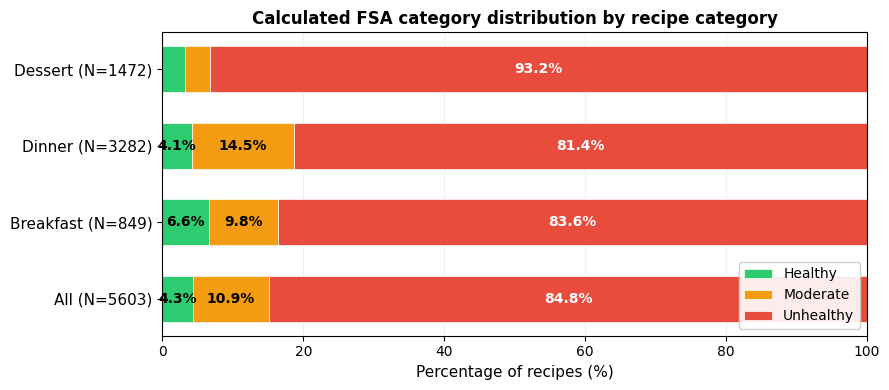

Saved: fsa_by_recipe_category_stacked.png


In [8]:
categories = ['All', 'Breakfast', 'Dinner', 'Dessert']
colors = {'Healthy': '#2ECC71', 'Moderate': '#F39C12', 'Unhealthy': '#E74C3C'}

pcts = []
for cat in categories:
    sub = all_df if cat == 'All' else all_df[all_df['category'] == cat.lower()]
    n = len(sub)
    h = (sub['calculated_fsa_category'] == 'healthy').sum() / n * 100
    m = (sub['calculated_fsa_category'] == 'moderate').sum() / n * 100
    u = (sub['calculated_fsa_category'] == 'unhealthy').sum() / n * 100
    pcts.append({'Category': cat, 'Healthy': h, 'Moderate': m, 'Unhealthy': u, 'N': n})

pct_df = pd.DataFrame(pcts).set_index('Category')

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('white')

y_pos = range(len(categories))
left = np.zeros(len(categories))

for label in ['Healthy', 'Moderate', 'Unhealthy']:
    vals = pct_df[label].values
    bars = ax.barh(y_pos, vals, left=left, color=colors[label],
                   edgecolor='white', linewidth=0.5, label=label, height=0.6)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 4:  # skip labels on slivers
            ax.text(left[i] + val / 2, i, f'{val:.1f}%',
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if label == 'Unhealthy' else 'black')
    left += vals

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{cat} (N={pct_df.loc[cat, 'N']:.0f})" for cat in categories], fontsize=11)
ax.set_xlabel('Percentage of recipes (%)', fontsize=11)
ax.set_xlim(0, 100)
ax.set_title('Calculated FSA category distribution by recipe category', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(axis='x', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('figures/fsa_by_recipe_category_stacked.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: fsa_by_recipe_category_stacked.png")

## Table 5.4 — Calculated FSA and WHO scores per recipe category

In [9]:
rows = []
for cat in ['breakfast', 'dinner', 'dessert']:
    sel = ALL[ALL['category']==cat]
    n = len(sel)
    fsa = sel['calculated_fsa_score'].mean()
    who = sel['calculated_who_score'].mean()
    h = (sel['fsa_cat']=='healthy').sum(); m = (sel['fsa_cat']=='moderate').sum(); u = (sel['fsa_cat']=='unhealthy').sum()
    rows.append([cat.title(), n, f'{fsa:.2f}', f'{who:.2f}', f'{100*h/n:.1f}%', f'{100*m/n:.1f}%', f'{100*u/n:.1f}%'])
n = len(ALL)
fsa = ALL['calculated_fsa_score'].mean(); who = ALL['calculated_who_score'].mean()
h = (ALL['fsa_cat']=='healthy').sum(); m = (ALL['fsa_cat']=='moderate').sum(); u = (ALL['fsa_cat']=='unhealthy').sum()
rows.append(['All', n, f'{fsa:.2f}', f'{who:.2f}', f'{100*h/n:.1f}%', f'{100*m/n:.1f}%', f'{100*u/n:.1f}%'])
df_per_cat = pd.DataFrame(rows, columns=['Category','N','Mean FSA','Mean WHO','Healthy','Moderate','Unhealthy'])
print('--- Table 5.4: By recipe category ---')
print(df_per_cat.to_string(index=False))

--- Table 5.4: By recipe category ---
 Category    N Mean FSA Mean WHO Healthy Moderate Unhealthy
Breakfast  849    10.14     2.81    6.6%     9.8%     83.6%
   Dinner 3282    10.31     2.71    4.1%    14.5%     81.4%
  Dessert 1472    10.79     2.03    3.2%     3.6%     93.2%
      All 5603    10.41     2.55    4.3%    10.9%     84.8%


## Table 5.5 — FSA traffic-light bands (top) and WHO criterion pass rates (bottom)

In [10]:
rows = []
n = len(ALL)
for label, col in [('Fat','calculated_fsa_fat_score'),
                   ('Saturated fat','calculated_fsa_sat_fat_score'),
                   ('Sugar','calculated_fsa_sugar_score'),
                   ('Salt','calculated_fsa_salt_score')]:
    g = (ALL[col]==1).sum(); a = (ALL[col]==2).sum(); r = (ALL[col]==3).sum()
    rows.append([label, f'{100*g/n:.1f}%', f'{100*a/n:.1f}%', f'{100*r/n:.1f}%'])
df_fsa_bands = pd.DataFrame(rows, columns=['Nutrient','Green','Amber','Red'])
print('--- Table 5.5 (top): FSA traffic-light bands ---')
print(df_fsa_bands.to_string(index=False))

--- Table 5.5 (top): FSA traffic-light bands ---
     Nutrient Green Amber   Red
          Fat  4.8%  0.7% 94.5%
Saturated fat 14.9%  0.1% 85.1%
        Sugar 34.0%  0.2% 65.8%
         Salt 24.9%  0.7% 74.4%


In [11]:
rows = []
n = len(ALL)
for label, col in [('Protein (10--15% energy)',       'calculated_who_protein'),
                   ('Fat (15--30% energy)',           'calculated_who_fat'),
                   ('Saturated fat ($<$10% energy)',  'calculated_who_sat_fat'),
                   ('Carbohydrates (55--75% energy)', 'calculated_who_carbs'),
                   ('Sugar ($<$10% energy)',          'calculated_who_sugar'),
                   ('Salt ($\\leq$0.2 g/serving)',      'calculated_who_salt'),
                   ('Fibre ($\\geq$3 g/100 kcal)',      'calculated_who_fibre')]:
    p = (ALL[col]==1).sum()
    rows.append([label, f'{100*p/n:.1f}%'])
df_who_pass = pd.DataFrame(rows, columns=['Criterion','Pass rate'])
print('--- Table 5.5 (bottom): WHO criterion pass rates ---')
print(df_who_pass.to_string(index=False))

--- Table 5.5 (bottom): WHO criterion pass rates ---
                     Criterion Pass rate
      Protein (10--15% energy)     17.2%
          Fat (15--30% energy)     33.8%
 Saturated fat ($<$10% energy)     49.8%
Carbohydrates (55--75% energy)     10.3%
         Sugar ($<$10% energy)     51.0%
    Salt ($\leq$0.2 g/serving)     20.4%
    Fibre ($\geq$3 g/100 kcal)     72.0%


## Table 5.6 — FSA red-band shares and WHO criterion pass rates per recipe category

In [12]:
rows = []
for cat in ['breakfast', 'dinner', 'dessert']:
    sel = ALL[ALL['category']==cat]
    n = len(sel)
    for label, col in [('Fat',           'calculated_fsa_fat_score'),
                       ('Saturated fat', 'calculated_fsa_sat_fat_score'),
                       ('Sugar',         'calculated_fsa_sugar_score'),
                       ('Salt',          'calculated_fsa_salt_score')]:
        g = (sel[col]==1).sum(); a = (sel[col]==2).sum(); r = (sel[col]==3).sum()
        rows.append([cat.title(), label, f'{100*g/n:.1f}%', f'{100*a/n:.1f}%', f'{100*r/n:.1f}%'])
df_fsa_by_cat = pd.DataFrame(rows, columns=['Category','Nutrient','Green','Amber','Red'])
print('--- Table 5.6 (FSA): FSA traffic-light bands per category x nutrient ---')
print(f'  N: Breakfast={ (ALL["category"]=="breakfast").sum() }, Dinner={(ALL["category"]=="dinner").sum()}, Dessert={(ALL["category"]=="dessert").sum()}')
print(df_fsa_by_cat.to_string(index=False))

--- Table 5.6 (FSA): FSA traffic-light bands per category x nutrient ---
  N: Breakfast=849, Dinner=3282, Dessert=1472
 Category      Nutrient Green Amber   Red
Breakfast           Fat  5.3%  3.5% 91.2%
Breakfast Saturated fat 11.5%  0.4% 88.1%
Breakfast         Sugar 38.9%  1.2% 60.0%
Breakfast          Salt 33.8%  1.6% 64.5%
   Dinner           Fat  4.2%  0.3% 95.5%
   Dinner Saturated fat 20.1%  0.0% 79.9%
   Dinner         Sugar 47.6%  0.0% 52.4%
   Dinner          Salt 12.3%  0.0% 87.7%
  Dessert           Fat  5.8%  0.0% 94.2%
  Dessert Saturated fat  5.2%  0.0% 94.8%
  Dessert         Sugar  1.1%  0.1% 98.8%
  Dessert          Salt 47.8%  1.7% 50.5%


In [13]:
criteria = [
    ('Protein',  'calculated_who_protein'),
    ('Fat',      'calculated_who_fat'),
    ('Sat fat',  'calculated_who_sat_fat'),
    ('Carbs',    'calculated_who_carbs'),
    ('Sugar',    'calculated_who_sugar'),
    ('Salt',     'calculated_who_salt'),
    ('Fibre',    'calculated_who_fibre'),
]
rows = []
for cat in ['breakfast', 'dinner', 'dessert']:
    sel = ALL[ALL['category']==cat]; n = len(sel)
    rows.append([cat.title()] + [f'{100*(sel[c]==1).sum()/n:.1f}%' for _, c in criteria])
n = len(ALL)
rows.append(['All'] + [f'{100*(ALL[c]==1).sum()/n:.1f}%' for _, c in criteria])
df_who_by_cat = pd.DataFrame(rows, columns=['Category'] + [label for label, _ in criteria])
print('--- Table 5.6 (WHO): WHO criterion pass rates per category ---')
print(df_who_by_cat.to_string(index=False))

--- Table 5.6 (WHO): WHO criterion pass rates per category ---
 Category Protein   Fat Sat fat Carbs Sugar  Salt Fibre
Breakfast   38.8% 30.7%   46.5% 19.2% 42.9% 24.9% 77.6%
   Dinner    5.0% 45.5%   63.3%  6.6% 74.0%  6.6% 69.6%
  Dessert   32.2%  9.7%   21.5% 13.2%  4.4% 48.4% 74.1%
      All   17.2% 33.8%   49.8% 10.3% 51.0% 20.4% 72.0%


## Figure 5.2 — Distribution of self-reported FSA scores by model

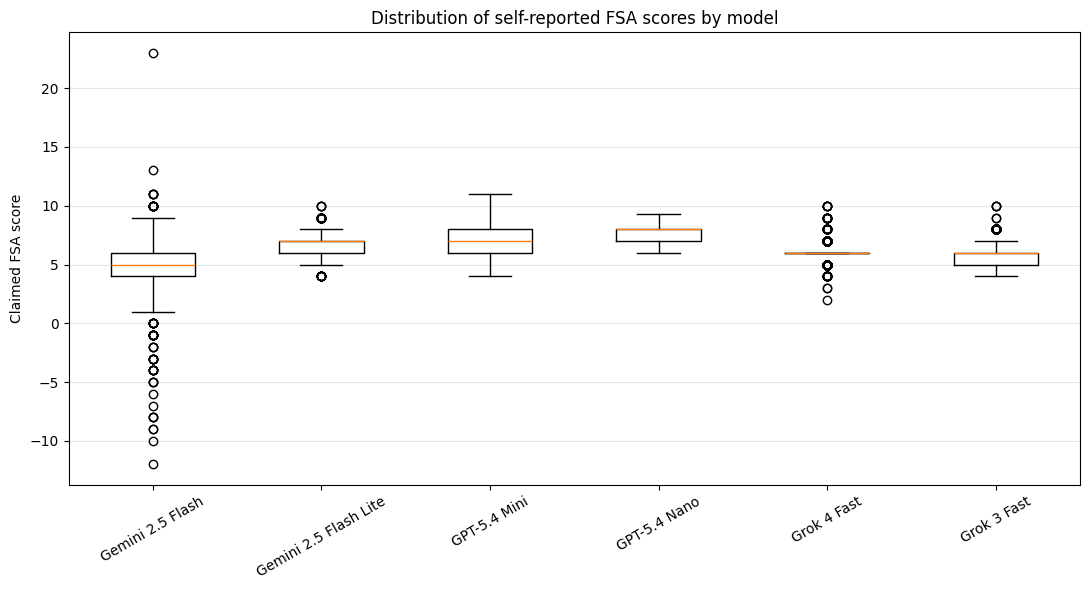

In [14]:
# Calculated FSA is bounded to 4-12 by construction; claimed can go outside that
# range because models sometimes produce nonsense scores.
claimed_fsa = [df['claimed_fsa_score'].dropna() for df in df_liste]
box_models = [df['model'].iloc[0] for df in df_liste]
display_labels = [MODEL_LABELS.get(m, m) for m in box_models]

fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot(claimed_fsa, tick_labels=display_labels)
ax.set_title('Distribution of self-reported FSA scores by model')
ax.set_ylabel('Claimed FSA score')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/fsa_boxplot_claimed.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 5.3 — Distribution of self-reported WHO scores by model

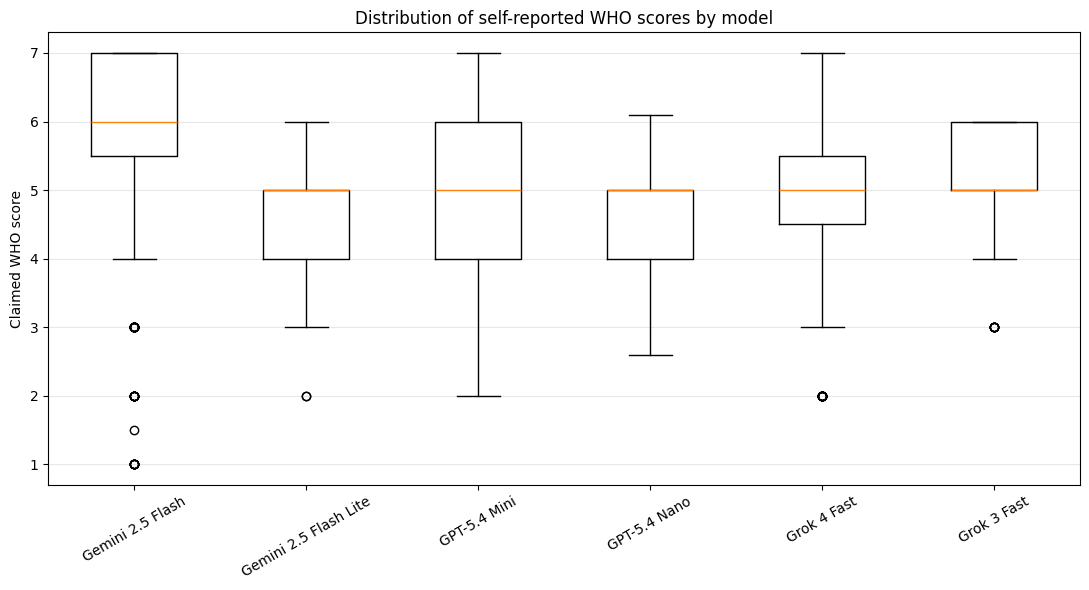

In [15]:
MODEL_LABELS = {
    'gemini_flash':      'Gemini 2.5 Flash',
    'gemini_flash_lite': 'Gemini 2.5 Flash Lite',
    'grok_fast':         'Grok 3 Fast',
    'grok4_fast':        'Grok 4 Fast',
    'gpt54_mini':        'GPT-5.4 Mini',
    'gpt54_nano':        'GPT-5.4 Nano',
}

claimed_who = [df['claimed_who_score'].dropna() for df in df_liste]
box_models = [df['model'].iloc[0] for df in df_liste]
display_labels = [MODEL_LABELS.get(m, m) for m in box_models]

fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot(claimed_who, tick_labels=display_labels)
ax.set_title('Distribution of self-reported WHO scores by model')
ax.set_ylabel('Claimed WHO score')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/who_boxplot_claimed.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 5.4 — FSA category distribution: calculated vs claimed

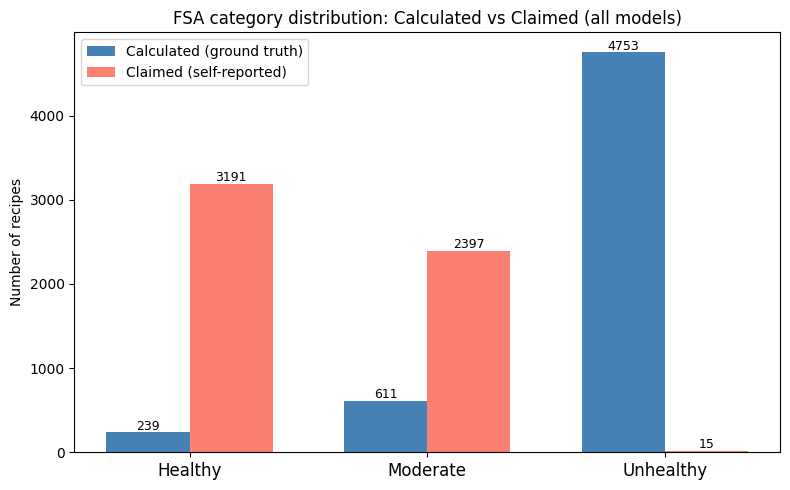

In [16]:
order  = ["healthy", "moderate", "unhealthy"]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]

calc_counts    = df_all["calculated_fsa_category"].str.lower().value_counts().reindex(order, fill_value=0)
claimed_counts = df_all["claimed_fsa_category"].str.lower().value_counts().reindex(order, fill_value=0)

x = np.arange(len(order))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, calc_counts.values,    width, label="Calculated (ground truth)", color="steelblue")
ax.bar(x + width/2, claimed_counts.values, width, label="Claimed (self-reported)",   color="salmon")
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in order], fontsize=12)
ax.set_ylabel("Number of recipes")
ax.set_title("FSA category distribution: Calculated vs Claimed (all models)")
ax.legend()
for i, v in enumerate(calc_counts.values):
    ax.text(i - width/2, v + 30, str(v), ha="center", fontsize=9)
for i, v in enumerate(claimed_counts.values):
    ax.text(i + width/2, v + 30, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/fsa_category_shift.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure 5.5 — Confusion matrix: calculated vs claimed FSA categories

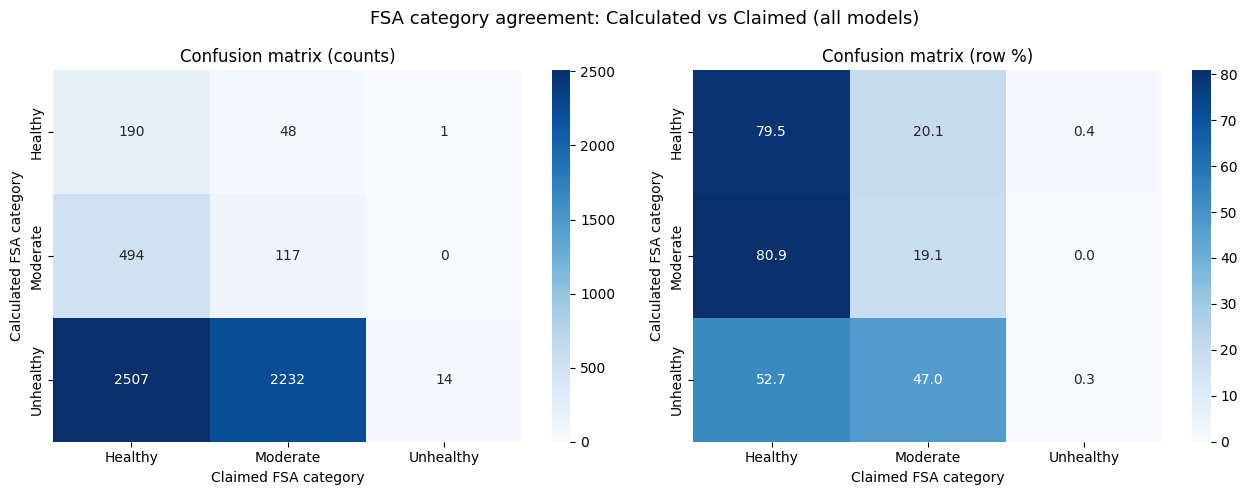


Row = Calculated (true), Column = Claimed (predicted)


In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

calc_cat  = df_all["calculated_fsa_category"].str.lower()
claim_cat = df_all["claimed_fsa_category"].str.lower()
mask      = calc_cat.notna() & claim_cat.notna()

cm = confusion_matrix(calc_cat[mask], claim_cat[mask], labels=order)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt="d", ax=axes[0],
            xticklabels=[c.capitalize() for c in order],
            yticklabels=[c.capitalize() for c in order],
            cmap="Blues")
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("Claimed FSA category")
axes[0].set_ylabel("Calculated FSA category")

sns.heatmap(cm_pct, annot=True, fmt=".1f", ax=axes[1],
            xticklabels=[c.capitalize() for c in order],
            yticklabels=[c.capitalize() for c in order],
            cmap="Blues")
axes[1].set_title("Confusion matrix (row %)")
axes[1].set_xlabel("Claimed FSA category")
axes[1].set_ylabel("Calculated FSA category")

plt.suptitle("FSA category agreement: Calculated vs Claimed (all models)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/fsa_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("\nRow = Calculated (true), Column = Claimed (predicted)")

## Figure 5.6 — Mean WHO score: calculated vs claimed by model

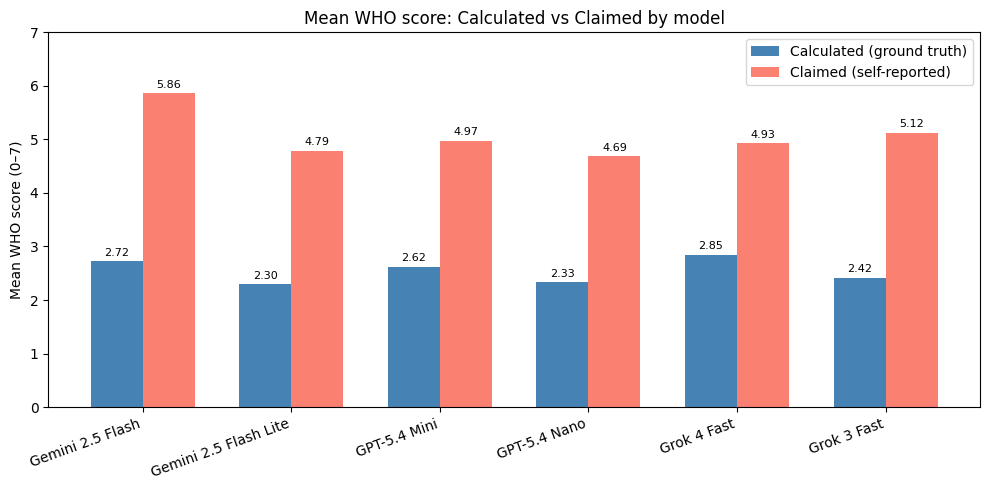

In [18]:
calc_who_means    = [pd.to_numeric(pd.read_csv(p)["calculated_who_score"], errors="coerce").mean() for p in files.values()]
claimed_who_means = [pd.to_numeric(pd.read_csv(p)["claimed_who_score"],    errors="coerce").mean() for p in files.values()]

x = np.arange(len(models))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, calc_who_means,    width, label="Calculated (ground truth)", color="steelblue")
bars2 = ax.bar(x + width/2, claimed_who_means, width, label="Claimed (self-reported)",   color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylabel("Mean WHO score (0–7)")
ax.set_ylim(0, 7)
ax.set_title("Mean WHO score: Calculated vs Claimed by model")
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{bar.get_height():.2f}", ha="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{bar.get_height():.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("figures/who_mean_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Table 5.7 — FSA decomposition per model

In [19]:
rows = []
tot = dict(n=0, cl=0.0, rec=0.0, calc=0.0, agree_cr=0, agree_rc=0)
for mid, _, label in MODELS:
    df = FRAMES[mid]
    n = len(df)
    cl = df['claimed_fsa_score'].mean(); rec = df['claimed_calc_fsa_score'].mean(); calc = df['calculated_fsa_score'].mean()
    cl_cat = df['claimed_fsa_category'].str.lower()
    rec_cat = df['claimed_calc_fsa_category'].str.lower()
    calc_cat = df['calculated_fsa_category'].str.lower()
    agree_cr = (cl_cat==rec_cat).sum(); agree_rc = (rec_cat==calc_cat).sum()
    rows.append([label, f'{cl:.2f}', f'{rec:.2f}', f'{calc:.2f}', f'{100*agree_cr/n:.1f}%', f'{100*agree_rc/n:.1f}%'])
    tot['n']+=n; tot['cl']+=df['claimed_fsa_score'].sum(); tot['rec']+=df['claimed_calc_fsa_score'].sum(); tot['calc']+=df['calculated_fsa_score'].sum()
    tot['agree_cr']+=agree_cr; tot['agree_rc']+=agree_rc
n=tot['n']
rows.append(['All', f'{tot["cl"]/n:.2f}', f'{tot["rec"]/n:.2f}', f'{tot["calc"]/n:.2f}', f'{100*tot["agree_cr"]/n:.1f}%', f'{100*tot["agree_rc"]/n:.1f}%'])
df_fsa_decomp = pd.DataFrame(rows, columns=['Model','Claimed','Recomputed','Calculated','Cl. vs Rec.','Rec. vs Calc.'])
print('--- Table 5.7: FSA decomposition ---')
print(df_fsa_decomp.to_string(index=False))

--- Table 5.7: FSA decomposition ---
            Model Claimed Recomputed Calculated Cl. vs Rec. Rec. vs Calc.
     Gemini Flash    4.83      10.27      10.21        5.8%         82.4%
Gemini Flash Lite    6.72      10.46      10.36        9.5%         81.0%
     GPT-5.4 Mini    7.13      10.28      10.69        2.7%         87.5%
     GPT-5.4 Nano    7.73      10.47      10.68        1.7%         87.5%
      Grok 4 Fast    6.05      10.43      10.17        3.3%         86.4%
      Grok 3 Fast    5.96       9.94      10.36        3.8%         88.7%
              All    6.40      10.30      10.41        4.4%         85.7%


## Table 5.8 — WHO decomposition per model

In [20]:
rows = []
tot = dict(n=0, cl=0.0, rec=0.0, calc=0.0)
for mid, _, label in MODELS:
    df = FRAMES[mid]
    n = len(df)
    cl = df['claimed_who_score'].mean(); rec = df['claimed_calc_who_score'].mean(); calc = df['calculated_who_score'].mean()
    rows.append([label, f'{cl:.2f}', f'{rec:.2f}', f'{calc:.2f}', f'{cl-rec:+.2f}', f'{rec-calc:+.2f}'])
    tot['n']+=n; tot['cl']+=df['claimed_who_score'].sum(); tot['rec']+=df['claimed_calc_who_score'].sum(); tot['calc']+=df['calculated_who_score'].sum()
n=tot['n']
cl=tot['cl']/n; rec=tot['rec']/n; calc=tot['calc']/n
rows.append(['All', f'{cl:.2f}', f'{rec:.2f}', f'{calc:.2f}', f'{cl-rec:+.2f}', f'{rec-calc:+.2f}'])
df_who_decomp = pd.DataFrame(rows, columns=['Model','Claimed','Recomputed','Calculated','Cl.\u2212Rec.','Rec.\u2212Calc.'])
print('--- Table 5.8: WHO decomposition ---')
print(df_who_decomp.to_string(index=False))

--- Table 5.8: WHO decomposition ---
            Model Claimed Recomputed Calculated Cl.−Rec. Rec.−Calc.
     Gemini Flash    5.86       2.91       2.72    +2.95      +0.18
Gemini Flash Lite    4.79       2.17       2.30    +2.62      -0.13
     GPT-5.4 Mini    4.97       2.73       2.62    +2.25      +0.10
     GPT-5.4 Nano    4.69       2.75       2.33    +1.94      +0.42
      Grok 4 Fast    4.93       2.85       2.85    +2.08      +0.00
      Grok 3 Fast    5.12       2.49       2.42    +2.63      +0.07
              All    5.06       2.65       2.55    +2.41      +0.10
